Этот ноутбук выполняет автоматизированный поиск набора акций Московской Биржи с минимальной попарной корреляцией для построения диверсифицированного портфеля. Сначала скрипт загружает список всех обыкновенных акций через API биржи, исключая привилегированные бумаги, затем скачивает их исторические цены и обороты с начала 2022 года с возможностью кэширования данных в CSV файл для ускорения повторных запусков. Полученные временные ряды проходят фильтрацию по ликвидности со средним дневным оборотом более 50 миллионов рублей (можно настроить), по наличию достаточного количества наблюдений и по ненулевой волатильности, после чего пропуски в данных заполняются методом экстраполяции. На основе очищенных данных рассчитывается матрица корреляций доходностей и строится граф, в котором связи между акциями устанавливаются только при коэффициенте корреляции ниже порога 0.15 (можно настроить). В завершение алгоритм находит максимальную клику в этом графе, выявляя тем самым наибольшую группу инструментов, чьи цены движутся наиболее независимо друг от друга.

In [25]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
from datetime import datetime
from dateutil.relativedelta import relativedelta
from tqdm import tqdm
from rich import print as rprint
import warnings
warnings.filterwarnings('ignore')

In [26]:
# Параметры
END_DATE = datetime.date(datetime.now())
START_DATE = END_DATE - relativedelta(years=2)
CORR_THRESHOLD = 0.25   # порог корреляции
MIN_OBSERVATIONS = 500  # минимум наблюдений для акции
MIN_TURNOVER = 50_000_000 # минимальны оборот для ликвидности

In [27]:
# Получаем список акций
def get_all_shares():
    url = "https://iss.moex.com/iss/engines/stock/markets/shares/securities.json"
    
    params = {
        "iss.meta": "off",
        "iss.only": "securities",
        "securities.columns": "SECID,SECNAME,SECTYPE"
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    df = pd.DataFrame(
        data['securities']['data'],
        columns=data['securities']['columns']
    )
    
    # оставляем только акции
    df = df[df['SECTYPE'] == '1']
    
    tickers = df['SECID'].unique().tolist()
    
    return tickers

rprint("Получаем список акций...")
tickers = get_all_shares()
rprint(f"Найдено акций: {len(tickers)}")

Получаем список акций...

Найдено акций: 211

In [28]:
# Загружаем цены
def get_price_history(ticker, start, end):
    url = f"https://iss.moex.com/iss/history/engines/stock/markets/shares/securities/{ticker}.json"
    
    all_data = []
    start_row = 0
    
    session = requests.Session()
    
    while True:
        params = {
            "from": start,
            "till": end,
            "iss.meta": "off",
            "history.columns": "TRADEDATE,CLOSE,VALUE",
            "start": start_row
        }
        
        try:
            response = session.get(url, params=params, timeout=10)
            data = response.json()
        except Exception:
            rprint(f"{ticker} — ошибка соединения, повтор...")
            time.sleep(1)
            continue
        
        if 'history' not in data:
            break
        
        rows = data['history']['data']
        
        if not rows:
            break
        
        all_data.extend(rows)
        
        if len(rows) < 100:
            break
        
        start_row += 100
        time.sleep(0.3)  # замедляемся внутри пагинации
    
    if not all_data:
        return None
    
    df = pd.DataFrame(all_data, columns=["TRADEDATE", "CLOSE", "VALUE"])
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    df = df.drop_duplicates(subset="TRADEDATE")
    df.set_index('TRADEDATE', inplace=True)
    df = df[~df.index.duplicated(keep='first')]
    df = df.rename(columns={
    "CLOSE": ticker,
    "VALUE": f"{ticker}_VALUE"
    })
    
    return df

rprint("Загружаем котировки...")

all_prices = []

try: 
    prices = pd.read_csv('data/price_data.csv', sep=';', index_col='TRADEDATE')
except Exception as e:
    for ticker in tqdm(tickers, desc="Загрузка тикеров"):    
        df = get_price_history(ticker, START_DATE, END_DATE)
        
        if df is None:
            tqdm.write(f"{ticker} — нет данных")
        elif len(df) < MIN_OBSERVATIONS:
            tqdm.write(f"{ticker} — мало наблюдений ({len(df)})")
        else:
            all_prices.append(df)
            # tqdm.write(f"{ticker} — добавлено ({len(df)} наблюдений)")

    prices = pd.concat(all_prices, axis=1)

    # 
    prices = prices.dropna(axis=1, thresh=0.8)

    # Заполняем пропуски: forward fill + backward fill для краёв
    prices = prices.ffill().bfill()

    # Теперь удаляем только те столбцы, где ВСЁ было NaN
    prices = prices.dropna(axis=1, how='all')

    rprint(f"Акций после обработки (со столбцами объёмов): {prices.shape[1]}\nПериодов: {prices.shape[0]}")

    prices.to_csv('data/price_data.csv', sep=';')

Загружаем котировки...

Загрузка тикеров:   3%|▎         | 7/211 [00:21<09:22,  2.76s/it]

APRI — мало наблюдений (406)


Загрузка тикеров:   5%|▍         | 10/211 [00:28<08:26,  2.52s/it]

BAZA — мало наблюдений (56)


...

YDEX — мало наблюдений (422)


Загрузка тикеров:  89%|████████▊ | 187/211 [07:25<00:34,  1.43s/it]

KFBA — мало наблюдений (180)


Загрузка тикеров: 100%|██████████| 211/211 [08:14<00:00,  2.34s/it]


Акций после обработки (со столбцами объёмов): 374
Периодов: 508

In [29]:
# Фильтрация полученных значений
# Отделяем цены и обороты
value_cols = [c for c in prices.columns if c.endswith("_VALUE")]
price_cols = [c for c in prices.columns if not c.endswith("_VALUE")]

values = prices[value_cols]
prices = prices[price_cols]

# --- средний дневной оборот ---
avg_turnover = values.mean()

# фильтр > установленной ликвидности
liquid = avg_turnover[avg_turnover > MIN_TURNOVER].index
liquid = [x.replace("_VALUE", "") for x in liquid]

prices = prices[liquid]

rprint("После фильтра ликвидности осталось:", len(prices.columns))

returns = prices.pct_change().dropna()

# убираем аномальные скачки (например, > 80% за день)
returns = returns[(returns.abs() < 0.8).all(axis=1)]

volatility = returns.std()

valid = volatility[volatility > 0].index
returns = returns[valid]

returns.to_csv('data/returns_data.csv', sep=';')

rprint("После фильтра волатильности осталось:", len(returns.columns))

После фильтра ликвидности осталось: 50

После фильтра волатильности осталось: 50

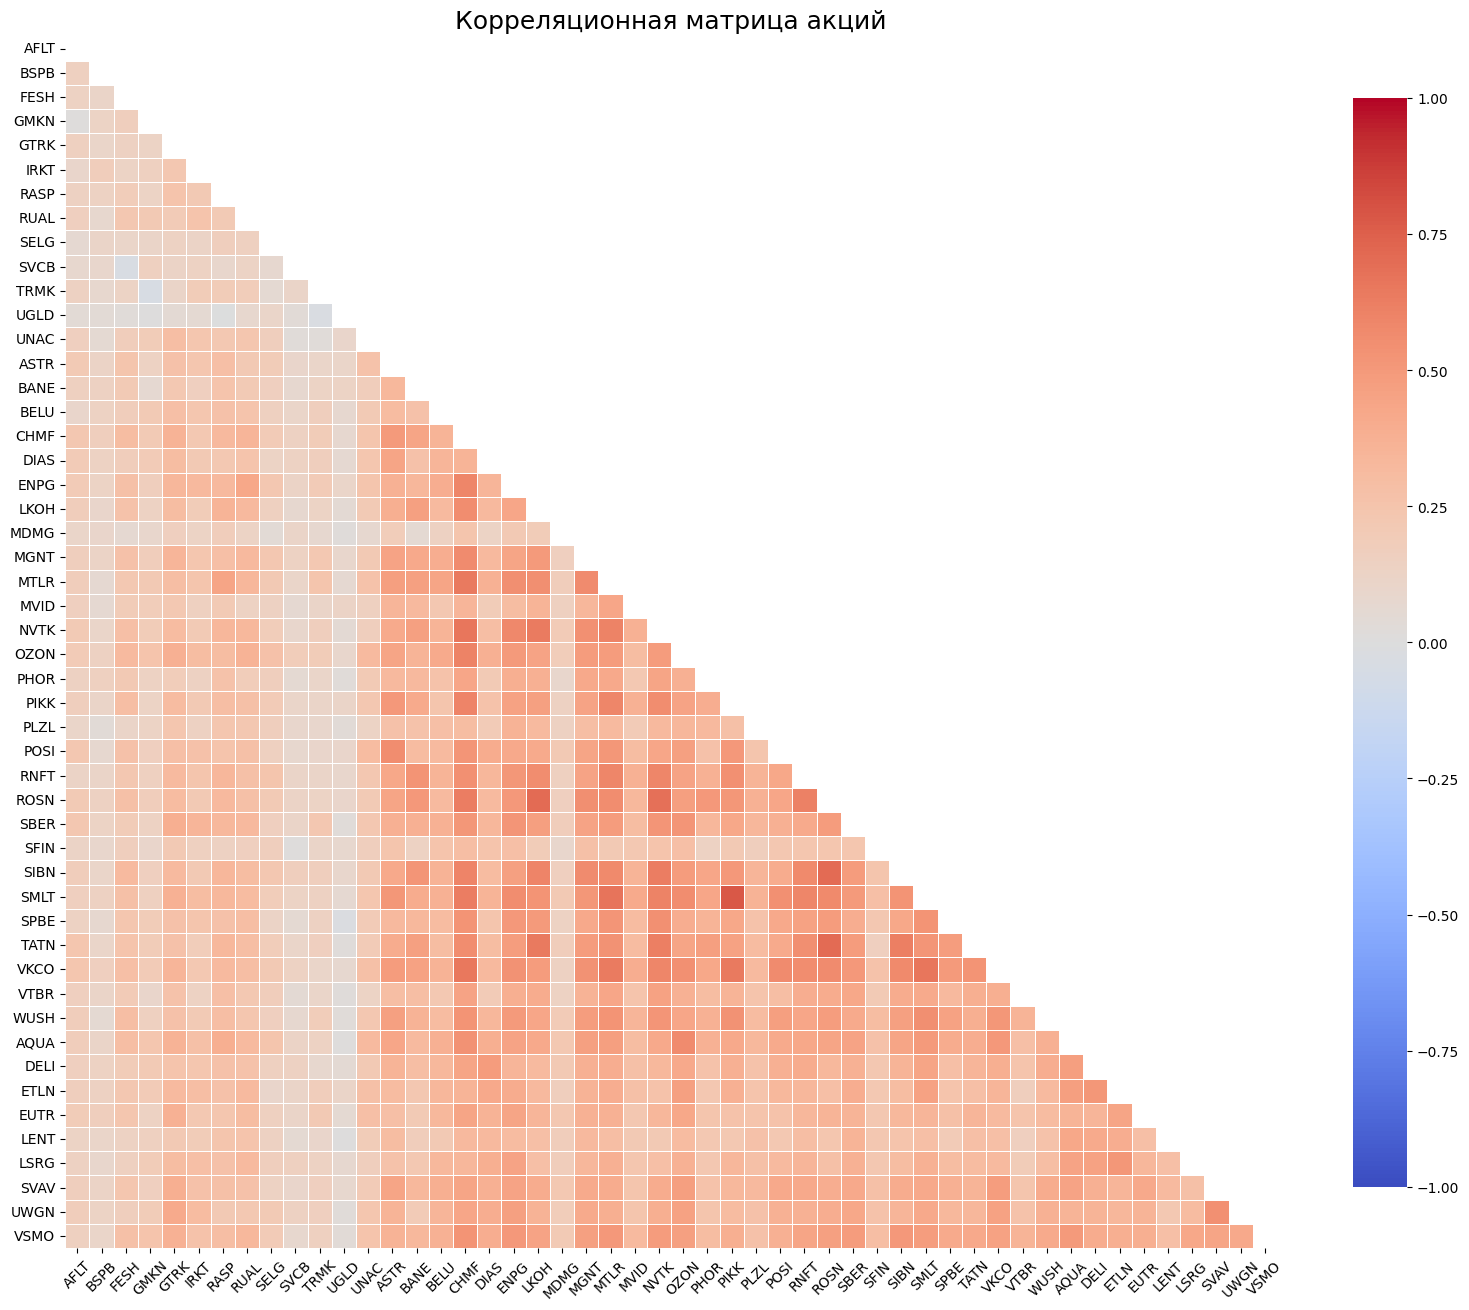

In [30]:
# Корреляционная матрица
corr_matrix = returns.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 14))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Корреляционная матрица акций", fontsize=18)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("figures/corr_matrix_shares.png")
plt.savefig("figures/corr_matrix_shares_transparent.png", transparent=True)
plt.show()

Количество вершин в графе: 50

Количество рёбер в графе: 525

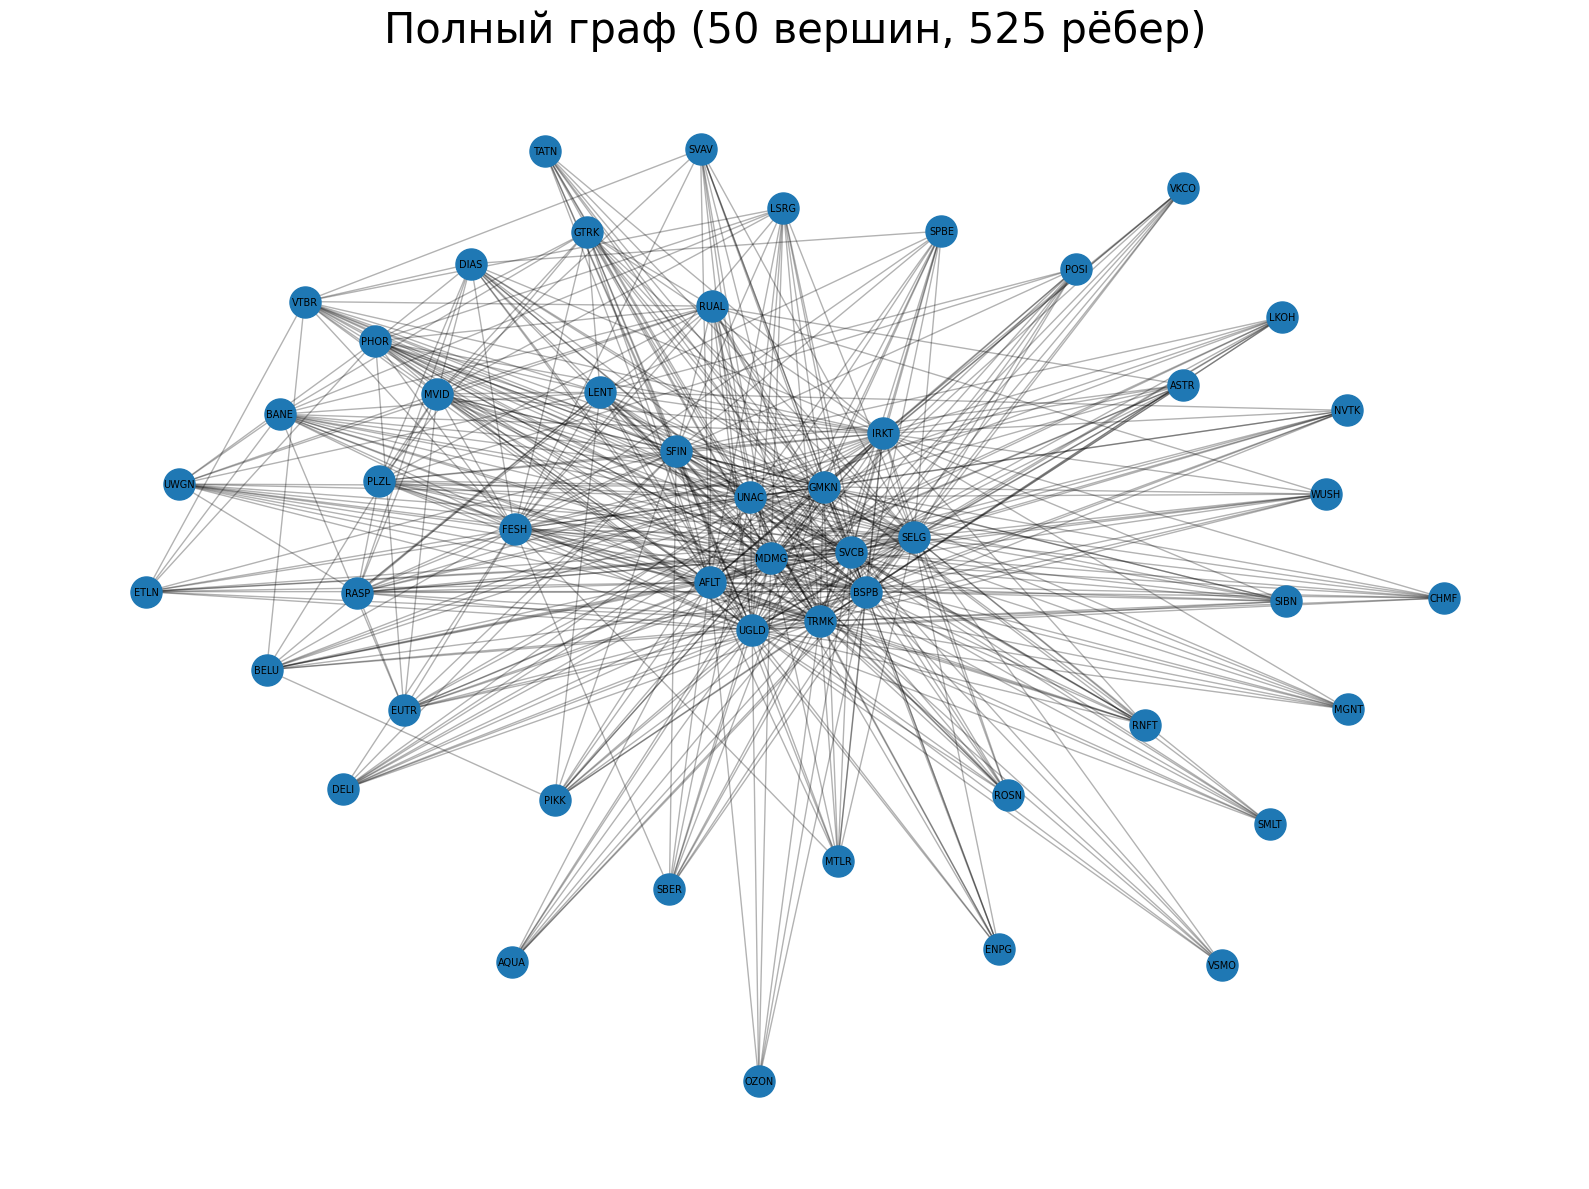

In [31]:
# Граф
G = nx.Graph()

for ticker in corr_matrix.columns:
    G.add_node(ticker)

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr = corr_matrix.iloc[i, j]
        if corr < CORR_THRESHOLD:
            G.add_edge(corr_matrix.columns[i],
                       corr_matrix.columns[j])

nodes = G.number_of_nodes()
edges = G.number_of_edges()
rprint("Количество вершин в графе:", nodes)
rprint("Количество рёбер в графе:", edges)

plt.figure(figsize=(16, 12))
graph = nx.spring_layout(G, seed=12345)
nx.draw_networkx_nodes(G, graph, node_size=500)
nx.draw_networkx_edges(G, graph, alpha=0.3)
nx.draw_networkx_labels(G, graph, font_size=7)
plt.title(f"Полный граф ({nodes} вершин, {edges} рёбер)", fontsize=30)
plt.axis("off")
plt.tight_layout()
plt.savefig('figures/full_graph.png')
plt.savefig("figures/full_graph_transparent.png", transparent=True)
plt.show()

In [32]:
# Поиск максимальной клики
rprint("Ищем клики...")
cliques = list(nx.find_cliques(G))

if len(cliques) == 0:
    rprint("Клики не найдены. Попробуй увеличить CORR_THRESHOLD.")
else:
    max_clique = max(cliques, key=len)
    
    rprint("Размер максимальной клики:", len(max_clique))
    rprint("Акции в клике:")
    rprint(max_clique)

Ищем клики...

Размер максимальной клики: 15

Акции в клике:

[
    'AFLT',
    'UGLD',
    'TRMK',
    'SVCB',
    'BSPB',
    'MDMG',
    'SELG',
    'GMKN',
    'GTRK',
    'SFIN',
    'FESH',
    'IRKT',
    'LENT',
    'PHOR',
    'MVID'
]

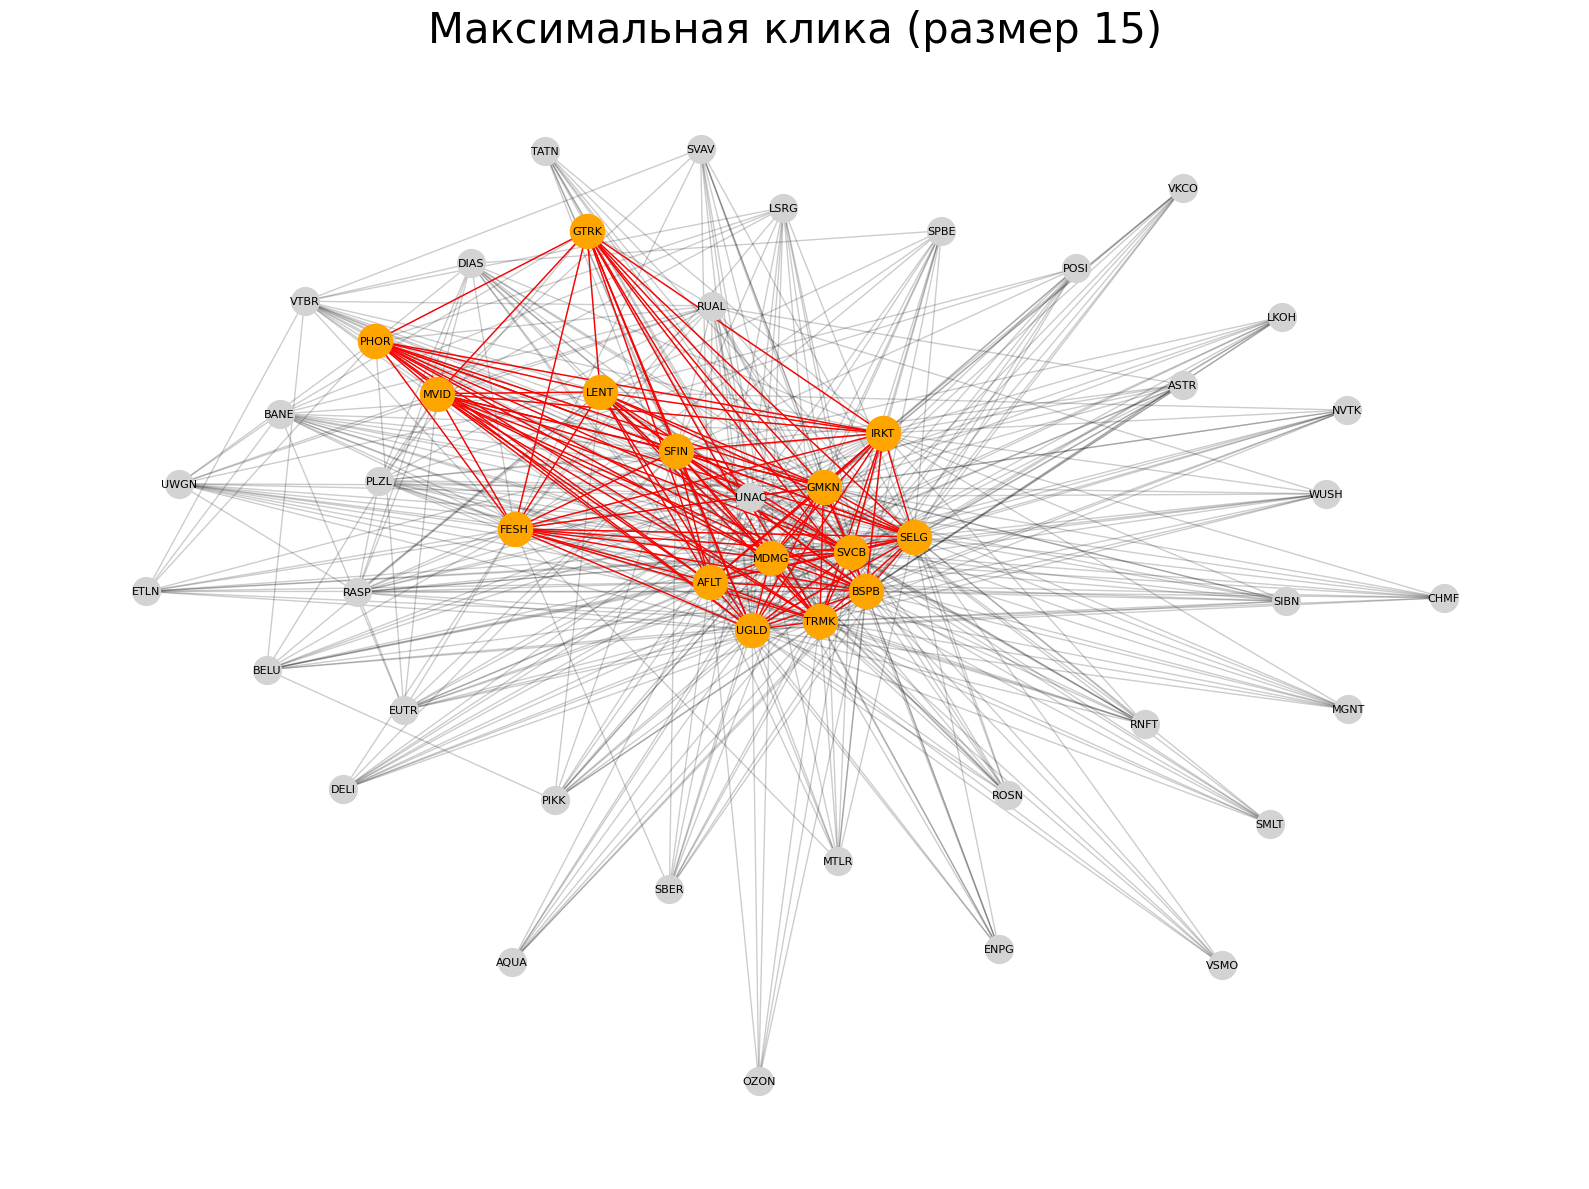

In [33]:
# График клики + граф
plt.figure(figsize=(16, 12))
nx.draw_networkx_nodes(G, graph, node_size=400, node_color='lightgray')
nx.draw_networkx_edges(G, graph, alpha=0.2)
clique_subgraph = G.subgraph(max_clique)

nx.draw_networkx_nodes(clique_subgraph, graph,
                       node_size=600,
                       node_color='orange')

nx.draw_networkx_edges(clique_subgraph, graph,
                       edge_color='red',
                       width=1)

nx.draw_networkx_labels(G, graph, font_size=8)

plt.title(f"Максимальная клика (размер {len(max_clique)})", fontsize=30)
plt.axis("off")
plt.tight_layout()
plt.savefig('figures/clique_and_graph.png')
plt.savefig('figures/clique_and_graph_transparent.png', transparent=True)
plt.show()

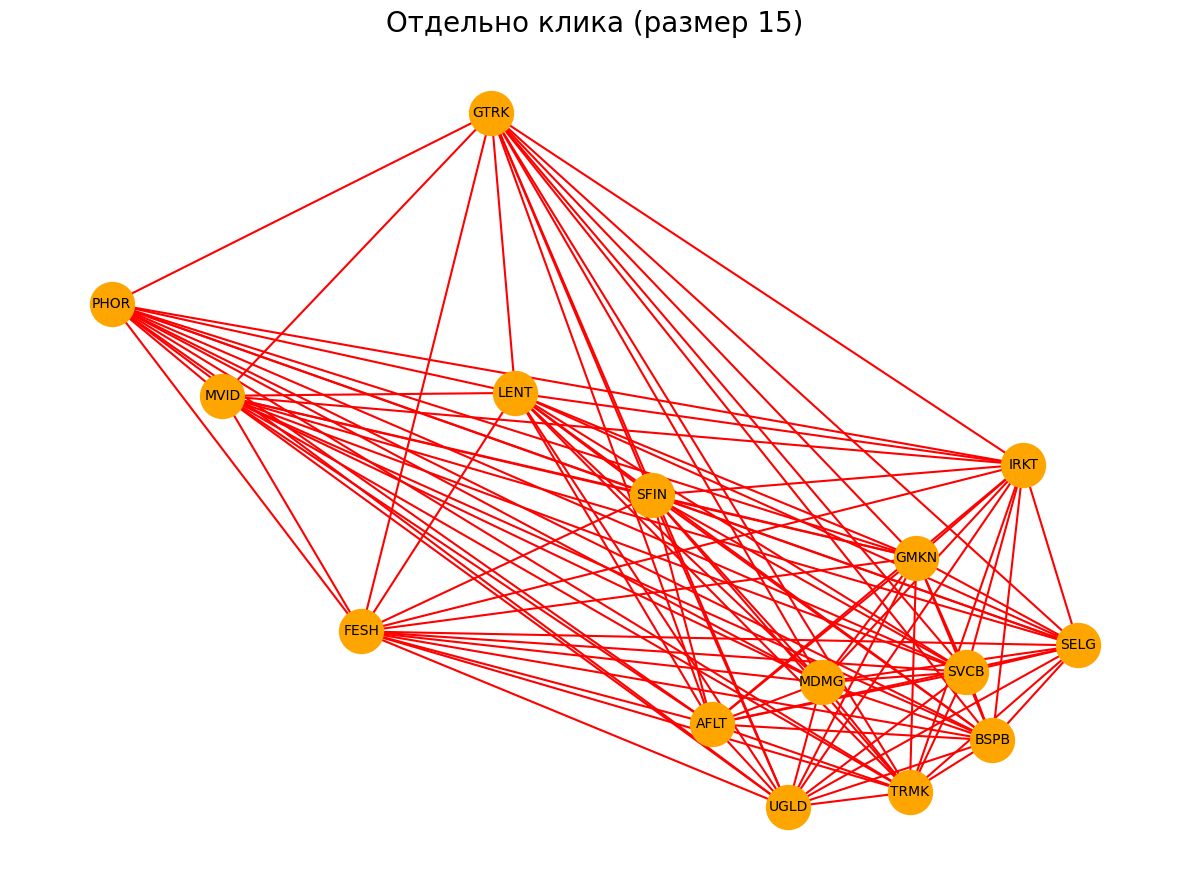

In [34]:
# График отдельно клики
plt.figure(figsize=(12, 9))

clique_subgraph = G.subgraph(max_clique)

nx.draw_networkx_nodes(clique_subgraph, graph,
                       node_size=1000,
                       node_color='orange')

nx.draw_networkx_edges(clique_subgraph, graph,
                       edge_color='red',
                       width=1.5)

nx.draw_networkx_labels(clique_subgraph, graph, font_size=10)

plt.title(f"Отдельно клика (размер {len(max_clique)})", fontsize=20)
plt.axis("off")
plt.tight_layout()
plt.savefig('figures/clique_separate.png')
plt.savefig('figures/clique_separate_transparent.png', transparent=True)
plt.show()


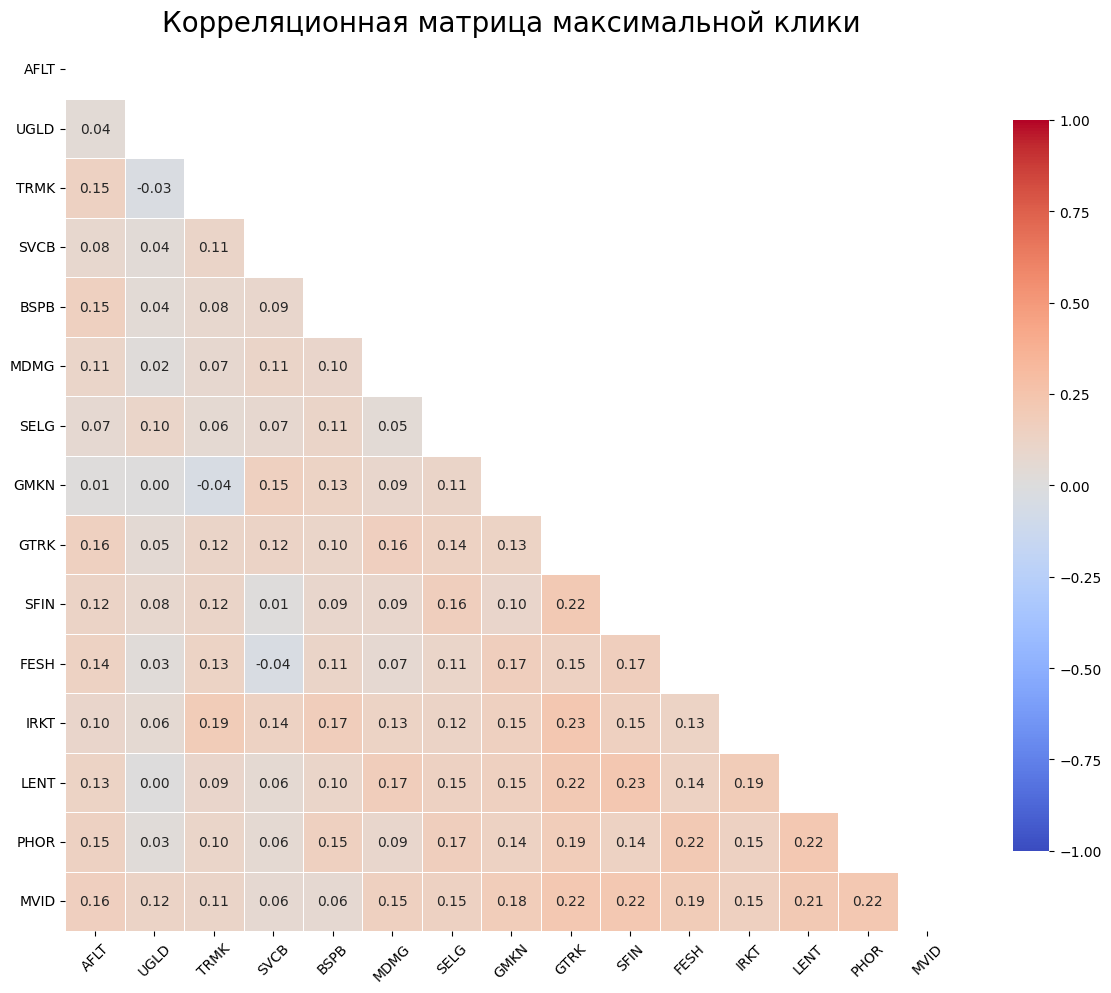

In [35]:
# Корреляция только для клики
clique_returns = returns[max_clique]
corr_matrix = clique_returns.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt='.2f',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Корреляционная матрица максимальной клики", fontsize=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/clique_corr_matrix.png')
plt.savefig('figures/clique_corr_matrix_transparent.png', transparent=True)
plt.show()

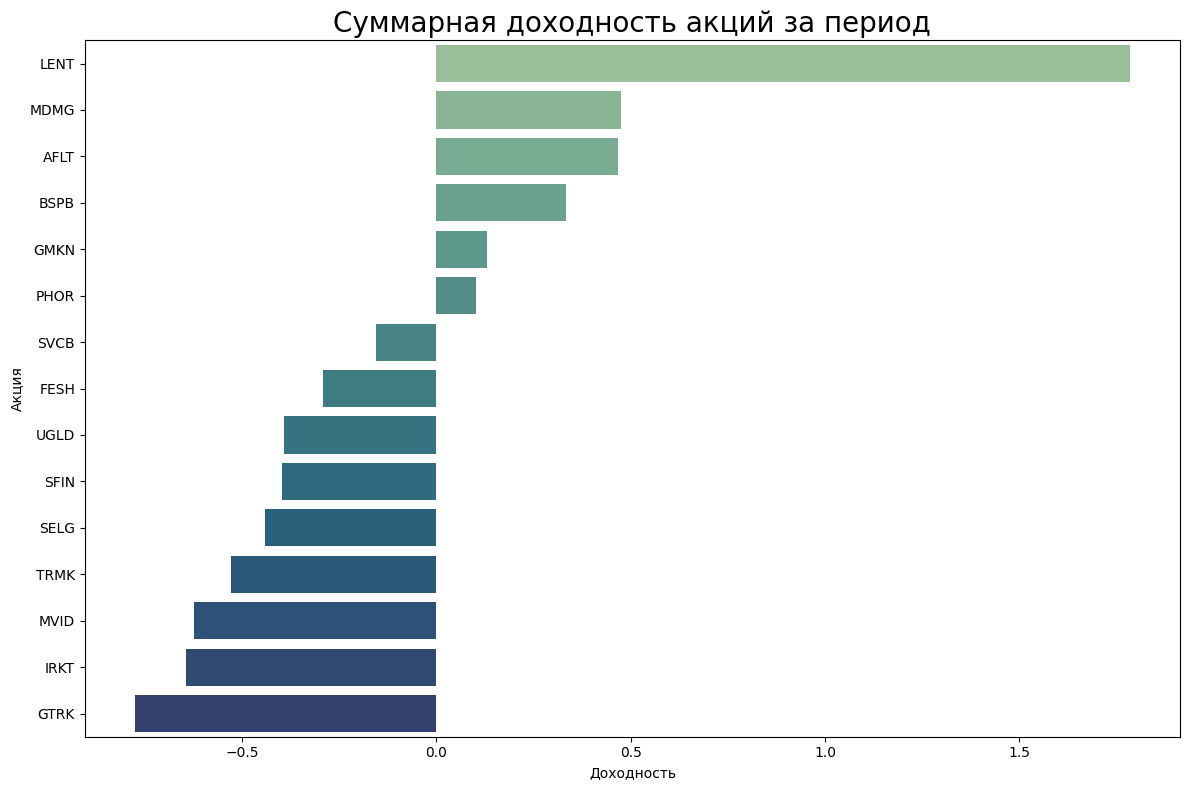

In [36]:
# Доходности только клики
clique_returns = returns[max_clique]

# Суммарная доходность за период
total_returns = (1 + clique_returns).prod() - 1

# Сортируем для красоты
total_returns = total_returns.sort_values(ascending=False)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=total_returns.values,
    y=total_returns.index,
    palette="crest"
)

plt.title("Суммарная доходность акций за период", fontsize=20)
plt.xlabel("Доходность")
plt.ylabel("Акция")
plt.tight_layout()
plt.savefig("figures/clique_total_returns.png")
plt.savefig("figures/clique_total_returns_transparent.png", transparent=True)
plt.show()